# Quantum-to-Game Mapping
We need to translate abstract quantum gate operations into "Game Tokens" that players can readily understand: 
1. Nodes and Qubits. Each level of the tree (or each move) corresponds to the introduction of a new qubit. 
2. Direction of Movement (Measurement Collapse): The measurement result of the qubit at the current level determines the direction of travel. A measurement of $|0\rangle$ results in a move Up-Left, while a measurement of $|1\rangle$ results in a move Up-Right. 
3. Superposition Token (Hadamard): When a player places this token at a node, it is equivalent to applying a Hadamard ($H$) gate to the current qubit. This creates a 50/50 superposition state, giving rise to an unpredictable quantum random walk. 
4. Entanglement Token (CNOT): This applies a Controlled-NOT ($CX$) gate. For instance, the node from the previous step serves as the Control qubit, while the current node serves as the Target qubit. This implies that the direction of the current step becomes "bound" to that of the previous step (either being exactly the same or exactly opposite); players can leverage this correlation to navigate around walls.

# Software Architecture
Maintain an "Operation History" list, dynamically constructing and rendering the quantum circuit from scratch during each round as needed.

Use two core classes:
1. QuantumEngine: Encapsulates the Qiskit logic, responsible for dynamically assembling the quantum circuit based on the instruction stream and performing measurements.
2. GameSession: Maintains the classical tree structure, the player's physical position (including wall collision status), the score, and the operation history; it also exposes interfaces for subsequent UI interactions.

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

In [ ]:
class QuantumEngine:
    """
    Handles all underlying Qiskit-related logic, dynamically generating circuits on demand.
    """
    def __init__(self):
        self.simulator = AerSimulator()
        
    def build_and_measure(self, operations):
        """
        Dynamically generate the circuit based on the operation history and measure the final step.
        operations example: [('H', 0), ('CX', 0, 1), ('H', 2)]
        """
        num_qubits = max([op[-1] for op in operations]) + 1 if operations else 1
        qr = QuantumRegister(num_qubits, 'q')
        cr = ClassicalRegister(1, 'c') # Only measure the current latest bit.
        qc = QuantumCircuit(qr, cr)
        
        # Dynamically Applying Quantum Gates
        for op in operations:
            gate = op[0]
            if gate == 'X':
                qc.x(op[1])
            elif gate == 'H':
                qc.h(op[1])
            elif gate == 'CX':
                qc.cx(op[1], op[2]) # op[1] is control, op[2] is target
                
        # Measure the current layer
        qc.measure(num_qubits - 1, 0)
        
        # Execute Simulation
        result = self.simulator.run(qc, shots=1).result()
        counts = result.get_counts()
        
        # Returns the measurement result ('0' or '1'), along with the generated circuit diagram for UI display.
        measured_state = list(counts.keys())[0]
        return measured_state, qc

class GameSession:
    """
    Manages game state and provides high-level API for UI interaction
    """
    def __init__(self, start_pos=0, bounds=(-3, 3)):
        self.position = start_pos  # 0 is the center; negative values ​​are to the left, and positive values ​​are to the right.
        self.bounds = bounds       # Wall-Collision Boundary
        self.step = 0              # Current tree depth
        self.history = []          # Record Quantum Operation Instructions
        self.engine = QuantumEngine()
        self.is_game_over = False
        
    def place_token_and_move(self, token_type, target_qubit=None, control_qubit=None):
        """UI Entry Point: Player places a Token, triggering a state update."""
        if self.is_game_over:
            print("Game Over!")
            return
            
        current_q = self.step
        
        # Parse the player's tokens and convert them into quantum gates.
        if token_type == 'Superposition':
            self.history.append(('H', current_q))
        elif token_type == 'Entanglement':
            if current_q == 0:
                print("Step 1 failed to generate entanglement; it defaults to a superposition state via a Hadamard gate.")
                self.history.append(('H', current_q))
            else:
                ctrl = control_qubit if control_qubit is not None else current_q - 1
                self.history.append(('CX', ctrl, current_q))
        elif token_type == 'Right':
            self.history.append(('X', current_q)) # Force set to |1>
        # The default setting is 'Left'—no action is taken, and the state remains |0>
        
        # The engine performs calculations.
        measured_state, circuit = self.engine.build_and_measure(self.history)
        
        # Update classical position based on collapse result
        if measured_state == '0':
            self.position -= 1  # Move left
            direction = "Up-Left"
        else:
            self.position += 1  # Move right
            direction = "Up-Right"
            
        self.step += 1
        self._check_collisions(direction)
        
        return {
            "step": self.step,
            "measured_state": f"|{measured_state}⟩",
            "direction": direction,
            "new_position": self.position,
            "circuit": circuit
        }
        
    def _check_collisions(self, direction):
        if self.position <= self.bounds[0] or self.position >= self.bounds[1]:
            self.is_game_over = True
            print(f"Measurement collapse caused movement to {direction}. Hit the wall, game over! Final position: {self.position}")

    def draw_current_circuit(self):
        """For Jupyter Notebook: Displays the evolution tree of the current quantum state."""
        if not self.history:
            return "No actions yet."
        _, qc = self.engine.build_and_measure(self.history)
        return qc.draw('mpl')

### Simulation the process of a player sequentially placing three distinct tokens, and renders a dynamically generated quantum circuit diagram.

========== Initializing Quantum Walk Game ==========
Initial Position: 0 (0 is center), Boundary: (-3, 3)

========== Step 1: Place [Superposition Token (H gate)] ==========
Quantum state collapsed to: |0⟩
Classical walk direction: Up-Left
Updated position: -1

========== Step 2: Place [Entanglement Token (CX gate)] ==========
Quantum state collapsed to: |1⟩ 
Classical walk direction: Up-Right
Updated position: 0

========== Step 3: Place [Force Right Token (X gate)] ==========
Quantum state collapsed to: |1⟩
Classical walk direction: Up-Right
Updated position: 1

========== Current Underlying Quantum Circuit ==========


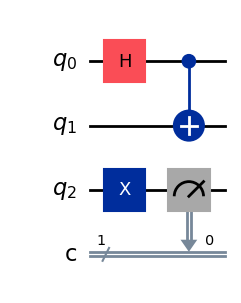

In [ ]:
from IPython.display import display

print("========== Initializing Quantum Walk Game ==========")
# Initialize the game, setting boundaries to [-3, 3] (Game Over if -3 or 3 is reached)
game = GameSession(start_pos=0, bounds=(-3, 3))
print(f"Initial Position: {game.position} (0 is center), Boundary: {game.bounds}\n")

print("========== Step 1: Place [Superposition Token (H gate)] ==========")
# Step 1 uses the H gate, creating a 50/50 probability to move Up-Left or Up-Right
result1 = game.place_token_and_move('Superposition')
if result1:
    print(f"Quantum state collapsed to: {result1['measured_state']}")
    print(f"Classical walk direction: {result1['direction']}")
    print(f"Updated position: {result1['new_position']}\n")

print("========== Step 2: Place [Entanglement Token (CX gate)] ==========")
# Step 2 uses the CX gate, using the previous qubit (q0) as control and current (q1) as target
# Note: This means q1's collapse will be highly correlated with q0 (directions will match in ideal simulation)
result2 = game.place_token_and_move('Entanglement')
if result2:
    print(f"Quantum state collapsed to: {result2['measured_state']} ")
    print(f"Classical walk direction: {result2['direction']}")
    print(f"Updated position: {result2['new_position']}\n")

print("========== Step 3: Place [Force Right Token (X gate)] ==========")
# Step 3 uses the X gate, equivalent to a "deterministic move," forcing the qubit to flip to |1>
result3 = game.place_token_and_move('Right')
if result3:
    print(f"Quantum state collapsed to: {result3['measured_state']}")
    print(f"Classical walk direction: {result3['direction']}")
    print(f"Updated position: {result3['new_position']}\n")

print("========== Current Underlying Quantum Circuit ==========")
# Extract and plot the quantum operations accumulated so far
fig = game.draw_current_circuit()
display(fig)